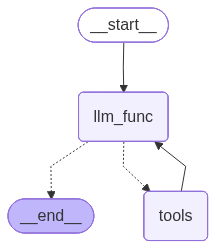

In [3]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

api_arxiv_wrapper = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
Arxiv = ArxivQueryRun(api_wrapper=api_arxiv_wrapper)

api_wiki_wrapper = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
Wiki = WikipediaQueryRun(api_wrapper=api_wiki_wrapper)

from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

def add(a:int,b:int)->int:
    """Docstring for add
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a+b

def mul(a:int,b:int)->int:
    """Docstring for mul
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a*b

def div(a:int,b:int)->int:
    """Docstring for div
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int
    """

    return a/b


tools = [add,mul,div,tavily,Arxiv,Wiki]

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm.bind_tools(tools=tools)

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage,AnyMessage
from langgraph.graph import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image,display

import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")

class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

def llm_func(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(State)

builder.add_node('llm_func',llm_func)
builder.add_node('tools',ToolNode(tools=tools))

builder.add_edge(START,'llm_func')
builder.add_conditional_edges('llm_func',##If the latest message (result) from assistant is a tool call->tool_condition routes to tools
                              # If the latest message (result) from assistant is not a tool call->tool_condition routes to END
                              tools_condition)

builder.add_edge('tools','llm_func')

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))





In [4]:
from langchain_core.messages import HumanMessage
messages = graph.invoke({"messages":HumanMessage(content="What is latest AI news,add 2+2 and then multiply by 5")})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

What is latest AI news,add 2+2 and then multiply by 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_YwCxDO2ACifzDPC7j2jjToIS)
 Call ID: call_YwCxDO2ACifzDPC7j2jjToIS
  Args:
    query: latest AI news
  add (call_MuCwhHFBzKRZ19CDrkjuaQPl)
 Call ID: call_MuCwhHFBzKRZ19CDrkjuaQPl
  Args:
    a: 2
    b: 2
  mul (call_Hcp7IXJ6EQjNIUtqHRyF9SfY)
 Call ID: call_Hcp7IXJ6EQjNIUtqHRyF9SfY
  Args:
    a: 4
    b: 5
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest AI News and AI Breakthroughs that Matter Most", "url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "content": "Date: October 26, 2025  \nSummary: Tesla, Inc. unveiled significant updates to its humanoid robot Optimus and AI systems, highlighting advances in dexterity, perceptio